In [2]:
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn", "requests"])

CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib', 'seaborn', 'requests'], returncode=0)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json


In [4]:
# Search Statistics Denmark's API for housing-related tables
response = requests.post(
    "https://api.statbank.dk/v1/subjects",
    json={"lang": "en", "recursive": True}
)
subjects = response.json()
print(json.dumps(subjects[:3], indent=2))  # peek at structure

[
  {
    "id": "1",
    "description": "People",
    "active": true,
    "hasSubjects": true,
    "subjects": [
      {
        "id": "3401",
        "description": "Population",
        "active": true,
        "hasSubjects": true,
        "subjects": [
          {
            "id": "20021",
            "description": "Population figures",
            "active": true,
            "hasSubjects": false,
            "subjects": []
          },
          {
            "id": "20024",
            "description": "Immigrants and their descendants",
            "active": true,
            "hasSubjects": false,
            "subjects": []
          },
          {
            "id": "20022",
            "description": "Population projections",
            "active": true,
            "hasSubjects": false,
            "subjects": []
          },
          {
            "id": "20019",
            "description": "Adoptions",
            "active": false,
            "hasSubjects": false,
            "su

In [5]:
# Searching for correct table in API
response = requests.post(
    "https://api.statbank.dk/v1/tableinfo",
    json={"table": "EJDFOE1", "lang": "en"}
)
meta = response.json()
print(f"Description: {meta.get('description', 'N/A')}")
for var in meta.get("variables", []):
    print(f"\n  Variable: {var['id']} — {var['text']}")
    for val in var["values"][:10]:
        print(f"    {val['id']}: {val['text']}")
    if len(var["values"]) > 10:
        print(f"    ... and {len(var['values']) - 10} more")

Description: Real estate market value by valuation, municipality of residence, unit, type of real estate and time

  Variable: VAERDI — valuation
    100: Market value
    105: Official real estate valuations 

  Variable: BOPKOM — municipality of residence
    000: All Denmark
    084: Region Hovedstaden
    101: Copenhagen
    147: Frederiksberg
    155: Dragør
    185: Tårnby
    165: Albertslund
    151: Ballerup
    153: Brøndby
    157: Gentofte
    ... and 94 more

  Variable: ENHED — unit
    100: Properties (Number)
    110: Total (DKK million)
    120: Average (DKK)

  Variable: EJENTYP — type of real estate
    T: TOTAL, REAL ESTATE
    A: One-family houses
    B: Flats (in a block of flats)
    C: Multi-family houses
    D: Houseing cooperative
    E: Residential properties associated with business
    F: Other residential properties
    G: Farms with buildings
    H: Holiday cottages
    I: Sites, farm land, areas of nature
    ... and 2 more

  Variable: Tid — time
    20

In [6]:
payload = {
    "table": "EJDFOE1",
    "lang": "en",
    "format": "JSONSTAT",
    "variables": [
        {"code": "VAERDI", "values": ["100"]},
        {"code": "BOPKOM", "values": ["*"]},
        {"code": "ENHED", "values": ["120"]},
        {"code": "EJENTYP", "values": ["*"]},
        {"code": "Tid", "values": ["*"]}
    ]
}

response = requests.post("https://api.statbank.dk/v1/data", json=payload)
raw = response.json()

print("Status:", response.status_code)
print("Keys:", list(raw.keys()))

Status: 200
Keys: ['dataset']


In [7]:
dataset = raw["dataset"]
print("Dataset keys:", list(dataset.keys()))

# Peek at each key's content
for key in dataset.keys():
    val = dataset[key]
    if isinstance(val, dict):
        print(f"\n{key} (dict) — keys: {list(val.keys())[:5]}")
    elif isinstance(val, list):
        print(f"\n{key} (list) — length: {len(val)}, first item: {val[0]}")
    else:
        print(f"\n{key}: {val}")

Dataset keys: ['dimension', 'label', 'source', 'updated', 'value', 'extension']

dimension (dict) — keys: ['VAERDI', 'BOPKOM', 'ENHED', 'EJENTYP', 'ContentsCode']

label: Real estate market value by valuation, municipality of residence, unit, type of real estate, Indhold and time

source: Statistics Denmark

updated: 2025-04-29T06:00:00Z

value (list) — length: 26208, first item: 1343784

extension (dict) — keys: ['px']


In [8]:
import itertools

dims = dataset["dimension"]

# Get all dimension values safely
def get_labels(dim):
    cat = dim["category"]
    if isinstance(cat, dict) and "label" in cat:
        return list(cat["label"].values())
    elif isinstance(cat, list):
        return cat
    else:
        return list(cat.values())

kommune_vals = get_labels(dims["BOPKOM"])
ejentyp_vals = get_labels(dims["EJENTYP"])
tid_vals = get_labels(dims["Tid"])

print(f"Municipalities: {len(kommune_vals)}")
print(f"Property types: {len(ejentyp_vals)}")
print(f"Years: {len(tid_vals)}")
print(f"Total combinations: {len(kommune_vals) * len(ejentyp_vals) * len(tid_vals)}")
print(f"Values in dataset: {len(dataset['value'])}")

Municipalities: 104
Property types: 12
Years: 21
Total combinations: 26208
Values in dataset: 26208


In [9]:
values = dataset["value"]
records = []
for i, combo in enumerate(itertools.product(kommune_vals, ejentyp_vals, tid_vals)):
    records.append({
        "municipality": combo[0],
        "property_type": combo[1],
        "year": int(combo[2]),
        "avg_value_dkk": values[i]
    })

df = pd.DataFrame(records)
df["avg_value_dkk"] = pd.to_numeric(df["avg_value_dkk"], errors="coerce")
df = df.dropna(subset=["avg_value_dkk"])

# Drop regional aggregates, keep only municipalities
exclude = ["All Denmark", "Region Hovedstaden", "Region Sjælland",
           "Region Syddanmark", "Region Midtjylland", "Region Nordjylland"]
df = df[~df["municipality"].isin(exclude)]

print(df.shape)
print(df["property_type"].unique())
df.head(10)

(24696, 4)
<StringArray>
[                             'TOTAL, REAL ESTATE',
                               'One-family houses',
                     'Flats (in a block of flats)',
                             'Multi-family houses',
                            'Houseing cooperative',
 'Residential properties associated with business',
                    'Other residential properties',
                            'Farms with buildings',
                                'Holiday cottages',
               'Sites, farm land, areas of nature',
                          'Commercial real estate',
                       'Other kinds of properties']
Length: 12, dtype: str


,municipality,property_type,year,avg_value_dkk
504,Copenhagen,"TOTAL, REAL ESTATE",2004,1216740
505,Copenhagen,"TOTAL, REAL ESTATE",2005,1576741
506,Copenhagen,"TOTAL, REAL ESTATE",2006,1896668
507,Copenhagen,"TOTAL, REAL ESTATE",2007,1873597
508,Copenhagen,"TOTAL, REAL ESTATE",2008,1673939
509,Copenhagen,"TOTAL, REAL ESTATE",2009,1499214
510,Copenhagen,"TOTAL, REAL ESTATE",2010,1629701
511,Copenhagen,"TOTAL, REAL ESTATE",2011,1547768
512,Copenhagen,"TOTAL, REAL ESTATE",2012,1580964
513,Copenhagen,"TOTAL, REAL ESTATE",2013,1668512


In [10]:
houses = df[df["property_type"] == "One-family houses"].copy()
print(houses["municipality"].nunique(), "municipalities")
print(houses["year"].min(), "–", houses["year"].max())

98 municipalities
2004 – 2024


In [11]:
sjaelland = [
    "Copenhagen", "Frederiksberg", "Dragør", "Tårnby", "Albertslund", "Ballerup",
    "Brøndby", "Gentofte", "Gladsaxe", "Glostrup", "Herlev", "Hvidovre", "Høje-Taastrup",
    "Ishøj", "Lyngby-Taarbæk", "Rødovre", "Vallensbæk", "Allerød", "Egedal", "Fredensborg",
    "Frederikssund", "Furesø", "Gribskov", "Halsnæs", "Helsingør", "Hillerød", "Hørsholm",
    "Rudersdal", "Lejre", "Roskilde", "Greve", "Køge", "Solrød", "Stevns", "Faxe",
    "Holbæk", "Kalundborg", "Næstved", "Odsherred", "Ringsted", "Slagelse", "Sorø",
    "Vordingborg", "Guldborgsund", "Lolland", "Møns", "Bornholm"
]

fyn = [
    "Odense", "Assens", "Faaborg-Midtfyn", "Kerteminde", "Langeland", 
    "Nordfyns", "Nyborg", "Svendborg", "Ærø"
]

jylland = [
    "Aarhus", "Aalborg", "Esbjerg", "Randers", "Vejle", "Horsens", "Kolding", "Silkeborg",
    "Herning", "Fredericia", "Viborg", "Skanderborg", "Hedensted", "Ikast-Brande",
    "Ringkøbing-Skjern", "Favrskov", "Norddjurs", "Syddjurs", "Odder", "Samsø",
    "Lemvig", "Struer", "Holstebro", "Skive", "Morsø", "Thisted", "Hjørring",
    "Frederikshavn", "Vesthimmerlands", "Rebild", "Mariagerfjord", "Jammerbugt",
    "Læsø", "Brønderslev", "Haderslev", "Sønderborg", "Tønder", "Aabenraa",
    "Vejen", "Billund", "Frederikshavn", "Middelfart", "Varde", "Fanø"
]

def get_region(municipality):
    if municipality in sjaelland:
        return "Sjælland"
    elif municipality in fyn:
        return "Fyn"
    elif municipality in jylland:
        return "Jylland"
    else:
        return "Other"

houses_m = houses.copy()
houses_m["avg_value_mdkk"] = houses_m["avg_value_dkk"] / 1_000_000
houses_m["region"] = houses_m["municipality"].apply(get_region)

# Check mapping worked
print(houses_m[houses_m["year"] == 2024]["region"].value_counts())

region
Sjælland    46
Jylland     43
Fyn          9
Name: count, dtype: int64


In [12]:
houses = df[df["property_type"] == "One-family houses"].copy()

houses_m = houses.copy()
houses_m["avg_value_mdkk"] = houses_m["avg_value_dkk"] / 1_000_000
houses_m["region"] = houses_m["municipality"].apply(get_region)

print(houses_m.columns.tolist())
print(houses_m["region"].value_counts())

['municipality', 'property_type', 'year', 'avg_value_dkk', 'avg_value_mdkk', 'region']
region
Sjælland    966
Jylland     903
Fyn         189
Name: count, dtype: int64


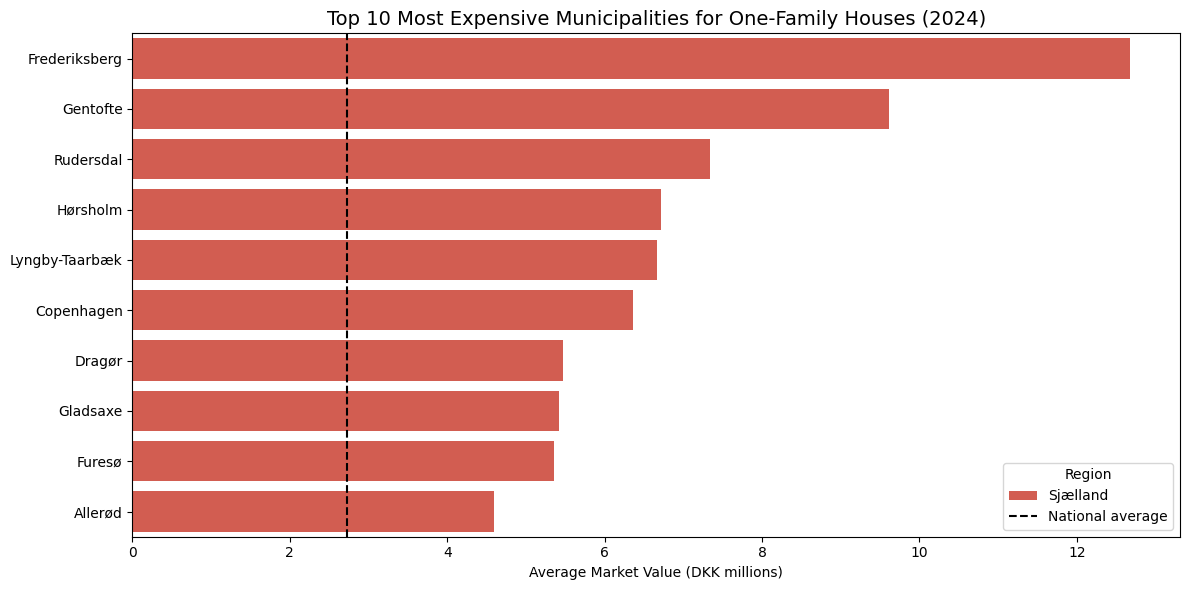

In [13]:
region_colors = {"Sjælland": "#e74c3c", "Jylland": "#3498db", "Fyn": "#2ecc71"}

top10 = (houses_m[houses_m["year"] == 2024]
         .sort_values("avg_value_mdkk", ascending=False)
         .head(10)
         .copy())

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x="avg_value_mdkk", y="municipality",
            hue="region", palette=region_colors, dodge=False)

plt.title("Top 10 Most Expensive Municipalities for One-Family Houses (2024)", fontsize=14)
plt.xlabel("Average Market Value (DKK millions)")
plt.ylabel("")
plt.axvline(x=houses_m[houses_m["year"] == 2024]["avg_value_mdkk"].mean(),
            color="black", linestyle="--", label="National average")
plt.legend(title="Region")
plt.tight_layout()
plt.savefig("top10_expensive.png", dpi=150)
plt.show()

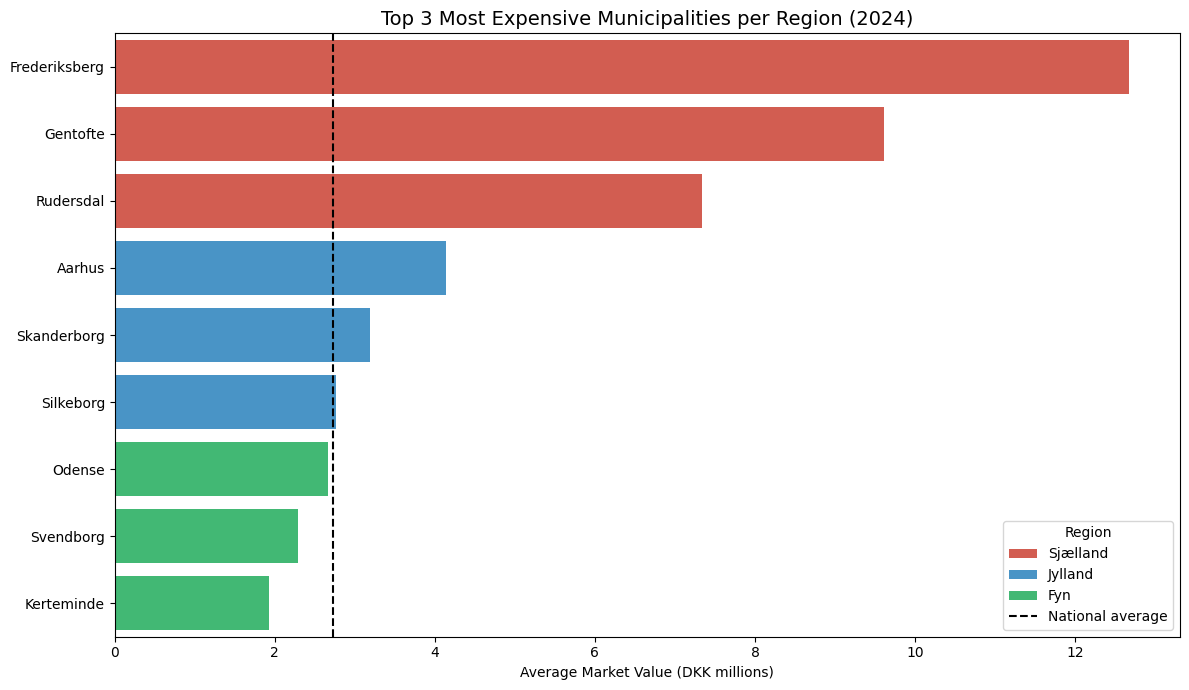

In [14]:
top3_per_region = (houses_m[houses_m["year"] == 2024]
                   .sort_values("avg_value_mdkk", ascending=False)
                   .groupby("region")
                   .head(3)
                   .sort_values("avg_value_mdkk", ascending=False)
                   .copy())

plt.figure(figsize=(12, 7))
sns.barplot(data=top3_per_region, x="avg_value_mdkk", y="municipality",
            hue="region", palette=region_colors, dodge=False)

plt.title("Top 3 Most Expensive Municipalities per Region (2024)", fontsize=14)
plt.xlabel("Average Market Value (DKK millions)")
plt.ylabel("")
plt.axvline(x=houses_m[houses_m["year"] == 2024]["avg_value_mdkk"].mean(),
            color="black", linestyle="--", label="National average")
plt.legend(title="Region")
plt.tight_layout()
plt.savefig("top3_per_region.png", dpi=150)
plt.show()

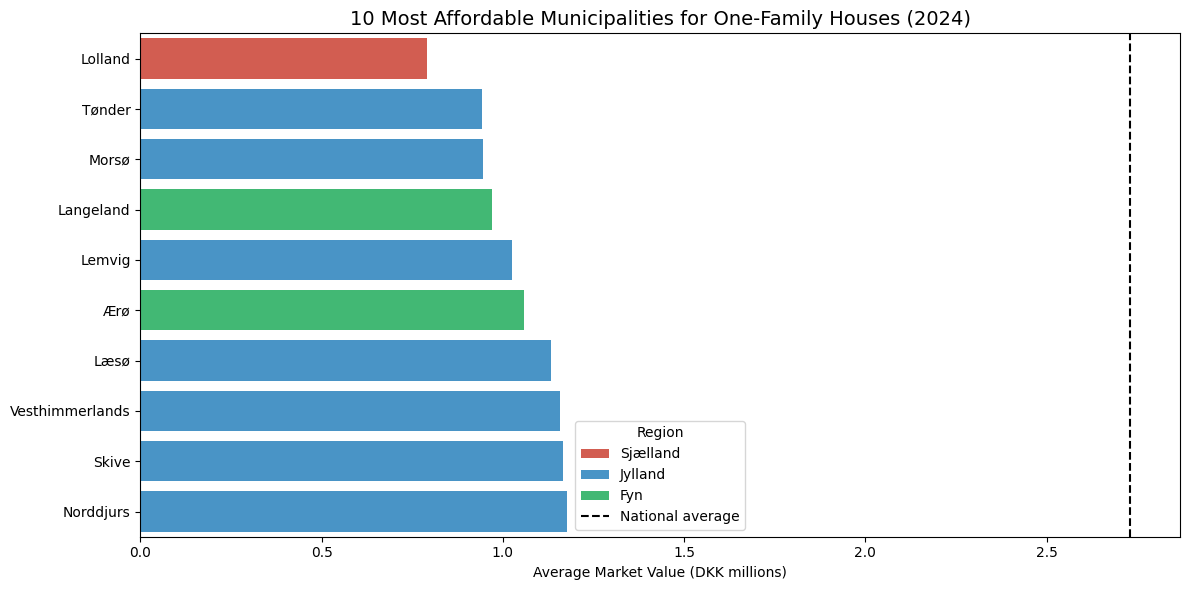

In [15]:
region_colors = {"Sjælland": "#e74c3c", "Jylland": "#3498db", "Fyn": "#2ecc71"}

bottom10 = (houses_m[houses_m["year"] == 2024]
            .sort_values("avg_value_mdkk", ascending=True)
            .head(10)
            .copy())

plt.figure(figsize=(12, 6))
sns.barplot(data=bottom10, x="avg_value_mdkk", y="municipality",
            hue="region", palette=region_colors, dodge=False)

plt.title("10 Most Affordable Municipalities for One-Family Houses (2024)", fontsize=14)
plt.xlabel("Average Market Value (DKK millions)")
plt.ylabel("")
plt.axvline(x=houses_m[houses_m["year"] == 2024]["avg_value_mdkk"].mean(),
            color="black", linestyle="--", label="National average")
plt.legend(title="Region")
plt.tight_layout()
plt.savefig("bottom10_affordable.png", dpi=150)
plt.show()

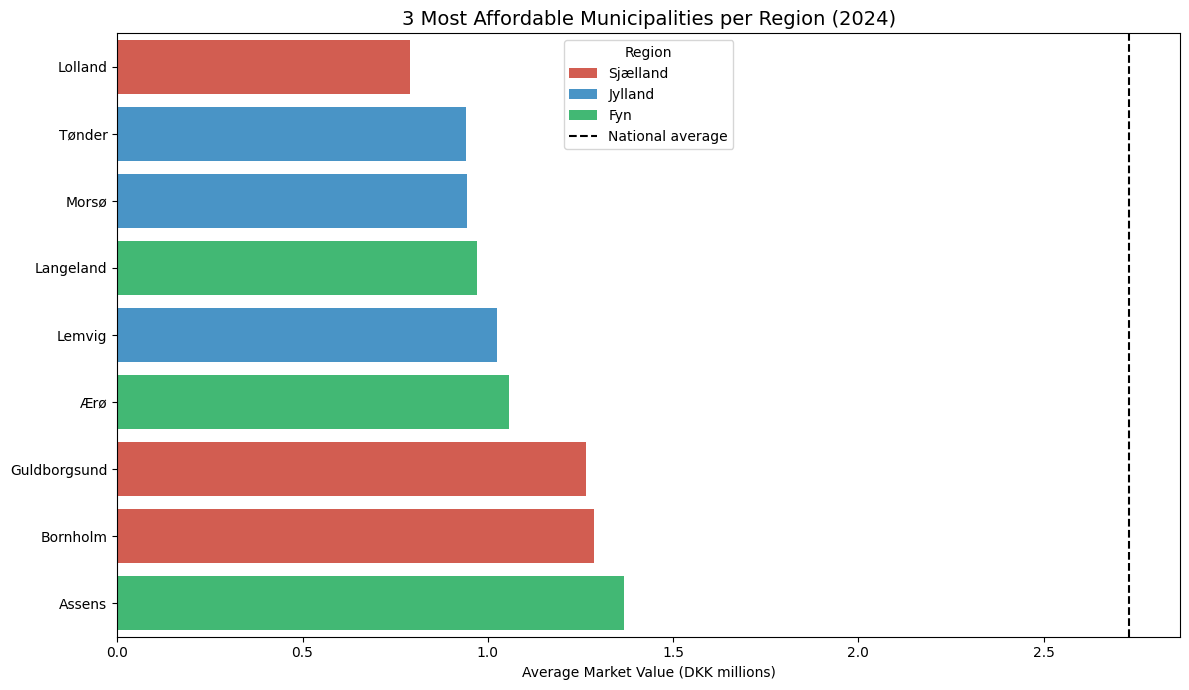

In [16]:
bottom3_per_region = (houses_m[houses_m["year"] == 2024]
                      .sort_values("avg_value_mdkk", ascending=True)
                      .groupby("region")
                      .head(3)
                      .sort_values("avg_value_mdkk", ascending=True)
                      .copy())

plt.figure(figsize=(12, 7))
sns.barplot(data=bottom3_per_region, x="avg_value_mdkk", y="municipality",
            hue="region", palette=region_colors, dodge=False)

plt.title("3 Most Affordable Municipalities per Region (2024)", fontsize=14)
plt.xlabel("Average Market Value (DKK millions)")
plt.ylabel("")
plt.axvline(x=houses_m[houses_m["year"] == 2024]["avg_value_mdkk"].mean(),
            color="black", linestyle="--", label="National average")
plt.legend(title="Region")
plt.tight_layout()
plt.savefig("bottom3_per_region.png", dpi=150)
plt.show()

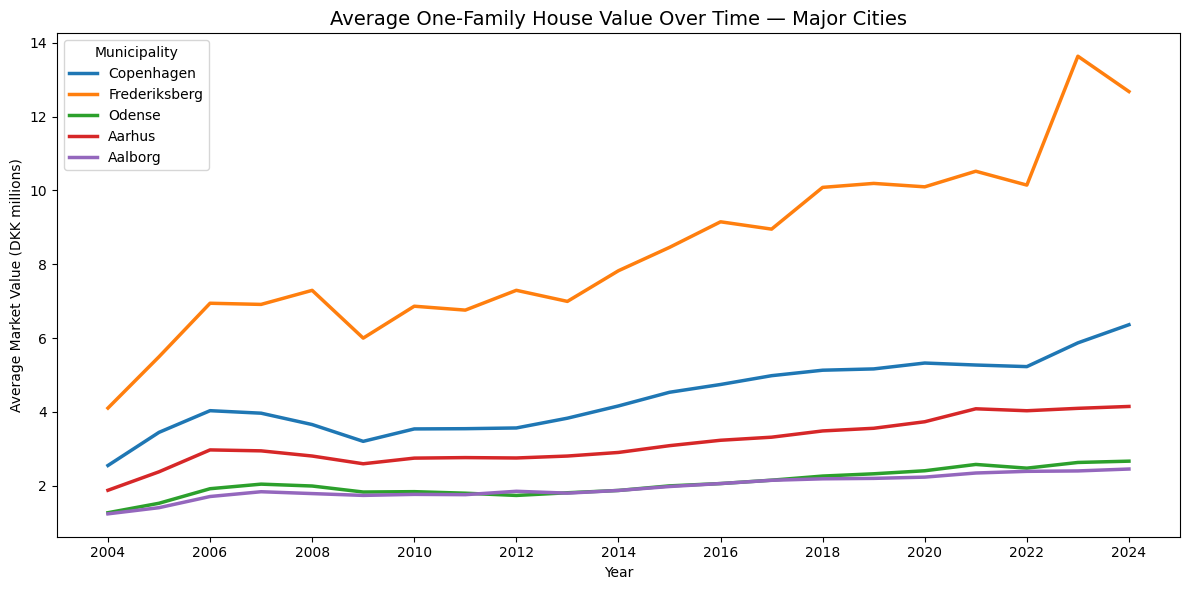

In [17]:
houses_m = houses.copy()
houses_m["avg_value_mdkk"] = houses_m["avg_value_dkk"] / 1_000_000
cities = ["Copenhagen", "Aarhus", "Odense", "Aalborg", "Frederiksberg"]
city_data = houses_m[houses_m["municipality"].isin(cities)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=city_data, x="year", y="avg_value_mdkk",
             hue="municipality", linewidth=2.5)

plt.title("Average One-Family House Value Over Time — Major Cities", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Market Value (DKK millions)")
plt.xticks(range(int(city_data["year"].min()), int(city_data["year"].max()) + 1, 2))
plt.legend(title="Municipality")
plt.tight_layout()
plt.savefig("city_trends.png", dpi=150)
plt.show()

In [19]:
houses = df[df["property_type"] == "One-family houses"].copy()
houses_m = houses.copy()
houses_m["avg_value_mdkk"] = houses_m["avg_value_dkk"] / 1_000_000
houses_m["region"] = houses_m["municipality"].apply(get_region)

print(houses_m.columns.tolist())

['municipality', 'property_type', 'year', 'avg_value_dkk', 'avg_value_mdkk', 'region']


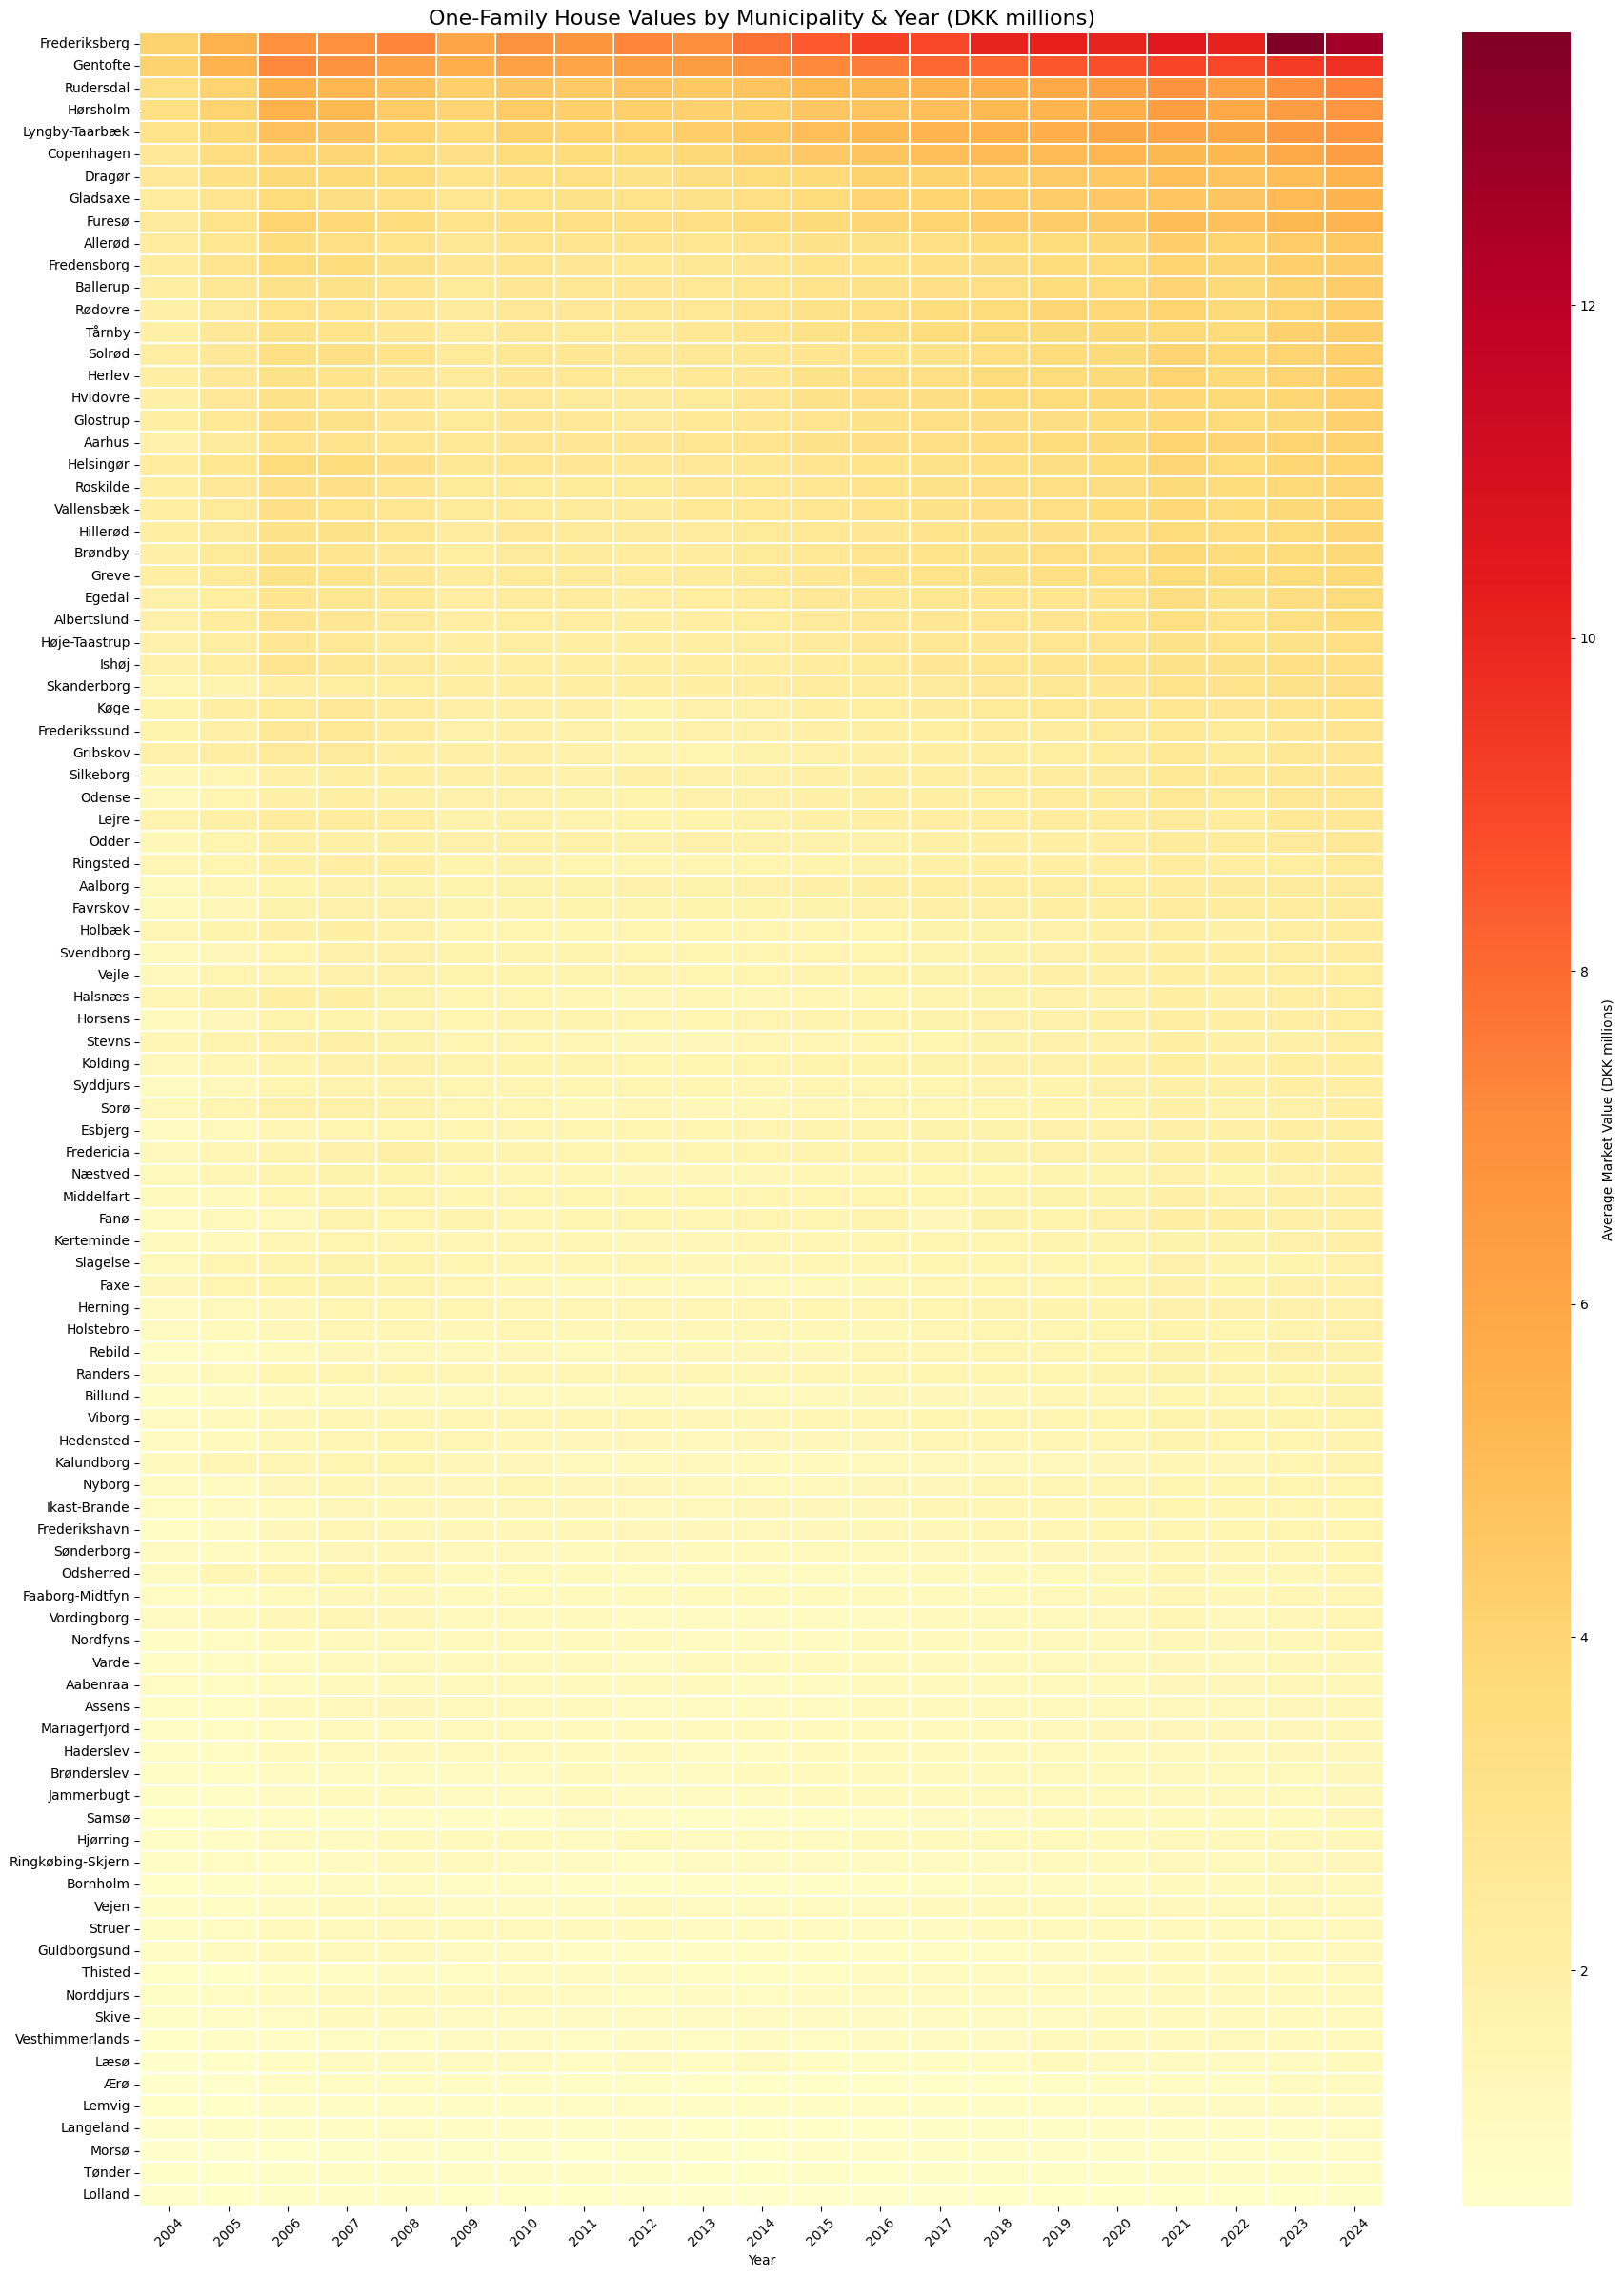

In [21]:
# Pivot data for heatmap — municipalities as rows, years as columns
heatmap_data = (houses_m[houses_m["region"] != "Other"]
                .groupby(["municipality", "year"])["avg_value_mdkk"]
                .mean()
                .unstack())

# Sort municipalities by 2024 value so most expensive are at the top
heatmap_data = heatmap_data.sort_values(2024, ascending=False)

plt.figure(figsize=(18, 24))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=False,
    cbar_kws={"label": "Average Market Value (DKK millions)"}
)

plt.title("One-Family House Values by Municipality & Year (DKK millions)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()

Key Findings: Danish Municipal Housing Market Analysis
=======================================================

1. REGIONAL DIVIDE: Sjælland dominates the top of the market — 19 of the top 20
   most expensive municipalities are on Sjælland, with Aarhus being the only
   Jylland municipality to break into the top 20.

2. MOST EXPENSIVE: Frederiksberg tops the list at ~12.6M DKK average market value
   for a one-family house, nearly 5x the national average of ~2.7M DKK.

3. MOST AFFORDABLE: The most affordable municipalities are concentrated in
   Jylland, offering one-family houses at a fraction of Copenhagen-area prices.

4. PRICE GROWTH: Copenhagen and Frederiksberg have seen the steepest price growth
   since 2004, accelerating sharply after 2012 following post-financial crisis recovery.

5. FINANCIAL CRISIS: The 2008 financial crisis caused a clear dip across all major
   cities, with prices not recovering to pre-crisis levels until around 2015-2016.
